# Task 1 — Forecasting Across Heterogeneous Sensors

AI651 / CS434 / EE5108 · implementation notebook

Use the Task 1 handout in `main.pdf` for concepts and response instructions. This notebook
contains the implementations, checks, and outputs for each part.

The simulated setting is a 20 Hz four-station production line. Products A, B, and C set global
nominal pace ranges of 14--18, 21--27, and 28--36 samples; each operating run has one actual pace from
its product range. Stations 1--3 are established and station 4 is held out.

Write every assessed response in your report. Each part has its own simple rhythm:
inspect its **Outputs**, then write its named **Response**.

| Part | You implement | Outputs | Response |
| --- | --- | --- | --- |
| 0. The World and Forecasting Setup | — | — | — |
| 1. Context-Dependent Forecasting | Raw Attention forecaster | 1.1–1.3 | 1A, 1B |
| 2. Separate Slow Structure from Repetition | `SeriesDecomposition.forward` | 2.1–2.3 | 2 |
| 3. Mix by Temporal Delay | `aggregate_delays` (`delay_scores` is supplied) | 3.1–3.2 | 3 |
| 4. Compare Designs and Deploy | — | 4.1–4.3 | 4 |

Short-horizon vibration forecasts provide the expected near-term baseline for condition monitoring.
Deviations from that expected behavior can indicate abnormal operation.

**Every implementation is checked where you write it.** Each implementation has a clear contract
and an immediate check; the numerical components also include small worked examples. Checks test
values, shapes, and gradients and name the likely cause when they fail. Nothing is left for a
training run to discover.


## 0. The World and Forecasting Setup

**Physical line:** Station 1 → Station 2 → Station 3 → Station 4. Each station has one vibration
accelerometer sampled at 20 Hz. Stations 1–3 are established; Station 4 is held out from fitting
but still supplies its own 96-sample context at inference time.

| Product | Actual pace in each operating run |
| --- | --- |
| A | 14–18 samples per cycle |
| B | 21–27 samples per cycle |
| C | 28–36 samples per cycle |

Each reading combines a slow drift, a repeating vibration, and small noise. A forecast receives
`L=96` readings from one station and predicts `H=48` future readings. Windows never cross a product
changeover. Train is samples 0–9600, validation is 9600–12480, and final test is 12480–15360.
Anchoring and scaling are supplied and use established-station training data only.

### Environment setup

Use Python 3.11 or later. From the unzipped assignment directory:

```bash
python -m venv .venv
# Linux/macOS:
source .venv/bin/activate
# Windows PowerShell:
# .venv\Scripts\Activate.ps1
python -m pip install -r requirements.txt
jupyter lab
```

For CPU-only PyTorch, install it from its CPU wheel index before installing the remaining
requirements:

```bash
python -m pip install torch --index-url https://download.pytorch.org/whl/cpu
python -m pip install -r requirements.txt
```

Keep `harness/` and `requirements.txt` beside this notebook.

#### Important: The notebook starts with PA1_PRESET=smoke only to make implementation and debugging fast. All results used in your report must come from a fresh PA1_PRESET=full run. 

In [1]:
import os
import math
import sys
from pathlib import Path

for candidate in (Path("harness"), Path("PA 01/harness"), Path("../harness")):
    if candidate.is_dir():
        sys.path.insert(0, str(candidate.resolve()))
        break
else:
    raise FileNotFoundError("Keep harness/ beside this notebook and start Jupyter there.")

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.nn import functional as F
from IPython.display import display
import design_controls as design
import design_data as data
import design_diagnostics as figures
import design_reporting as report

preset = os.environ.get("PA1_PRESET", "smoke")
seed = int(os.environ.get("PA1_SEED", "0"))
model_seed = int(os.environ.get("PA1_MODEL_SEED", str(seed)))
study = design.Study(preset, seed, model_seed=model_seed)
assert design.check_world(study.world)
print(f"preset={preset}; data seed={seed}; model seed={model_seed}; device={design.device}")
print(f"sampling rate={data.SAMPLING_RATE_HZ:g} Hz; products={', '.join(study.world.product_names)}")
print(f"product pace ranges={study.world.product_period_bands.tolist()} samples; "
      f"established stations={study.established.sum()}; held-out station=4")
print(f"eligible train/validation/test origins: "
      f"{len(study.region('train')['origins'])}/"
      f"{len(study.region('validation')['origins'])}/"
      f"{len(study.region('test')['origins'])}")



Four-station product-line world checks passed.
preset=full; data seed=0; model seed=0; device=cuda
sampling rate=20 Hz; products=Product A, Product B, Product C
product pace ranges=[[14.0, 18.0], [21.0, 27.0], [28.0, 36.0]] samples; established stations=3; held-out station=4
eligible train/validation/test origins: 650/105/105


## 1. Context-Dependent Forecasting

The handout ends Part 1 by wrapping Attention in an encoder and naming the result
**Raw Attention**: the forecaster every later section improves. Building it is your first
implementation, and it has to exist before any of Part 1's evidence can be produced.

Before the comparison, write the ordering you expect for **Response 1A**.

Produces **Outputs 1.1–1.3** → used in **Responses 1A and 1B**.


### My expected ordering (written before running Output 1.1)

**Stations 1–3, best to worst:** Period-routed ridge → Raw Attention → Shared ridge →
Sensor-specific ridge

**Held-out station 4, best to worst:** Period-routed ridge → Raw Attention → Shared ridge.
Sensor-specific ridge cannot be used here, because it has no matrix for station 4.

Why I expect this:

- **Period-routed ridge** is told the one thing that really changes between runs, which is how
  fast the line is turning. It then uses a rule made for that speed, so I expect it to be the best.
- **Raw Attention** is not told the speed. It has to work it out from the window, and the big slow
  drift gets in the way. I expect it to be good, but behind period-routed ridge.
- **Shared ridge** uses one fixed rule for every speed, so it can only give a middle answer that
  suits no speed well.
- **Sensor-specific ridge** only knows which station the window came from. The speed still changes
  inside every station, so this does not fix the real problem, and each of its matrices is fitted
  on only a third of the windows. I expect it to be about the same as shared ridge, or slightly
  worse.
- On **station 4** I expect Raw Attention to lose a little, because it never saw that sensor. The
  ridge rules depend on the speed, and station 4 turns at the same speed as the others, so they
  should lose very little.


### Assemble the forecaster

At this point there is only one model: **Raw Attention**. It embeds the raw context, uses
Attention to mix positions, then predicts the next 48 readings.

Routine layers are complete. **You write the `RawAttentionForecaster.forward` assembly.**
Input `context` is `[B, L, 1]`; `self.embed` wants `[B, channels, L]` and returns `[B, d, L]`;
the encoder blocks use `[B, L, d]`; flatten that final representation before the forecast head
to return `[B, H]`.

The next cell immediately checks the output shape and gradient flow.


In [2]:
class DenseAttention(nn.Module):
    def __init__(self, d, heads):
        super().__init__()
        if d % heads:
            raise ValueError("width must be divisible by heads")
        self.heads = heads
        self.query, self.key, self.value = (nn.Linear(d, d) for _ in range(3))
        self.out = nn.Linear(d, d)
        self.last_attention = None

    def forward(self, x):                       # [B,L,d]
        batch, length, width = x.shape
        shape = (batch, length, self.heads, width // self.heads)
        q, k, v = (layer(x).view(shape).transpose(1, 2)
                   for layer in (self.query, self.key, self.value))  # [B,h,L,d_h]
        weights = (q @ k.transpose(-1, -2) / math.sqrt(q.shape[-1])).softmax(-1)
        self.last_attention = weights.detach()  # [B,h,L,L]
        mixed = (weights @ v).transpose(1, 2).reshape(batch, length, width)
        return self.out(mixed)                  # [B,L,d]

class RawAttentionBlock(nn.Module):
    def __init__(self, d, heads, dropout):
        super().__init__()
        self.mix = DenseAttention(d, heads)
        self.norm1, self.norm2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.feed_forward = nn.Sequential(
            nn.Linear(d, 2 * d), nn.GELU(), nn.Dropout(dropout), nn.Linear(2 * d, d))
        self.drop = nn.Dropout(dropout)
    def forward(self, x):                       # [B,L,d]
        x = x + self.drop(self.mix(self.norm1(x)))
        return x + self.drop(self.feed_forward(self.norm2(x)))

class RawAttentionForecaster(nn.Module):
    def __init__(self, context=96, horizon=48, channels=1, d=64, heads=4, layers=2,
                 dropout=0.1):
        super().__init__()
        self.embed = nn.Conv1d(channels, d, 3, padding=1, padding_mode="circular", bias=False)
        self.position = nn.Parameter(torch.randn(1, context, d) * 0.02)
        self.blocks = nn.ModuleList([RawAttentionBlock(d, heads, dropout)
            for _ in range(layers)])
        self.norm = nn.LayerNorm(d)
        self.forecast_head = nn.Linear(context * d, horizon)

    def forward(self, context):                 # context [B,L,1] -> return [B,H]
        # self.embed wants [B,1,L], then produces [B,d,L]. After transposing back, add
        # self.position, pass through every block and self.norm, flatten [B,L,d], and use
        # self.forecast_head to return [B,H].
        encoded = self.embed(context.transpose(1, 2)).transpose(1, 2) + self.position
        for block in self.blocks:
            encoded = block(encoded)
        return self.forecast_head(self.norm(encoded).flatten(1))
    @property
    def attention_layers(self):
        return [block.mix for block in self.blocks if isinstance(block.mix, DenseAttention)]



In [3]:
assert design.check_raw_attention_assembly(RawAttentionForecaster)
design.register_components(raw_forecaster_type=RawAttentionForecaster)


Raw-Attention assembly and gradient checks passed.


### Evidence

| Cell below | Output | Read it for |
| --- | --- | --- |
| fit Raw Attention, then compare four forecasters | 1.1 | Response 1A — then revise the ordering you wrote |
| the same station under two products | 1.2 | Response 1B |
| Attention behaviour across two contexts | 1.3 | Response 1B |

The three ridge forecasters are supplied; you implement nothing for them.


In [4]:
study.train("Raw Attention")
report.publish("1.1", report.comparison(
    study, ["Shared ridge", "Sensor-specific ridge", "Period-routed ridge", "Raw Attention"]))


Raw Attention: 6000 steps, 51.2s, 368368 parameters, best established-validation MSE 0.211 (m/s²)² -- same physical units as the report tables below
Raw Attention: saved raw-attention-full-data0-model0-d826136d93e5.pt
Output 1.1


,model,established stations RMSE (m/s²),established stations MSE (m/s²)²,"established stations, Product A RMSE","established stations, Product B RMSE","established stations, Product C RMSE",held-out station 4 RMSE (m/s²),held-out station 4 MSE (m/s²)²,"held-out station 4, Product A RMSE","held-out station 4, Product B RMSE","held-out station 4, Product C RMSE",parameters,fit seconds
0,Shared ridge,0.767,0.588,0.805,0.854,0.621,0.876,0.767,0.909,0.982,0.713,4608,0.009
1,Sensor-specific ridge,0.768,0.590,0.804,0.852,0.630,unavailable,unavailable,unavailable,unavailable,unavailable,13824,0.002
2,Period-routed ridge,0.166,0.028,0.181,0.164,0.152,0.173,0.03,0.184,0.182,0.15,59904,0.004
3,Raw Attention,0.460,0.211,0.419,0.509,0.446,0.706,0.499,0.74,0.686,0.692,368368,51.211


Output 1.2


,station,product,actual period (samples),model,window RMSE (m/s²)
0,1,Product A,16.135,Shared ridge,0.779
1,1,Product A,16.135,Sensor-specific ridge,0.787
2,1,Product A,16.135,Period-routed ridge,0.232
3,1,Product A,16.135,Raw Attention,0.283
4,1,Product C,30.093,Shared ridge,0.448
5,1,Product C,30.093,Sensor-specific ridge,0.436
6,1,Product C,30.093,Period-routed ridge,0.150
7,1,Product C,30.093,Raw Attention,0.364


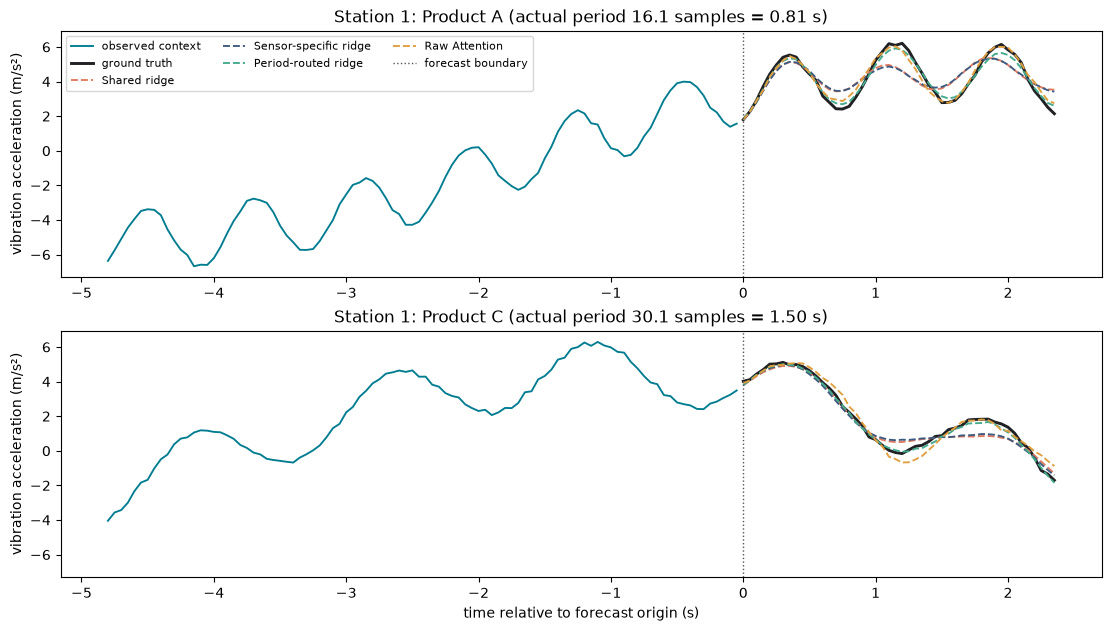

In [5]:
report.publish("1.2", figures.regime_forecasts(
    study, ["Shared ridge", "Sensor-specific ridge", "Period-routed ridge", "Raw Attention"]))


Output 1.3


,station,product,actual period (samples),mean |Attention weight difference|,max |Attention weight difference|
0,1,Product A,16.135,unavailable,unavailable
1,1,Product C,30.093,unavailable,unavailable
2,1,Product A vs Product C (difference),unavailable,0.012,0.359


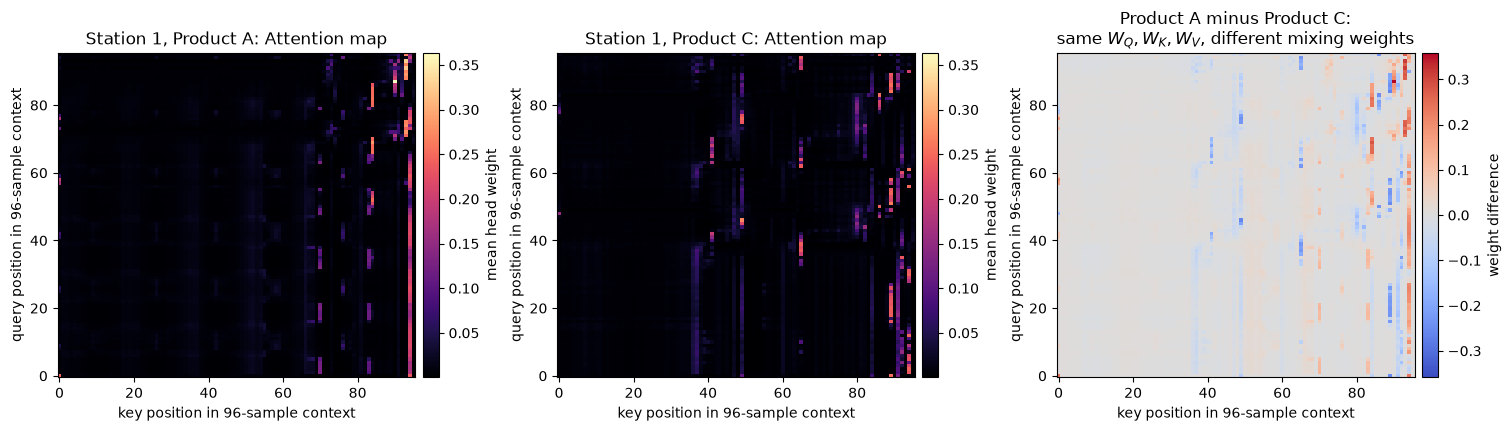

In [6]:
report.publish("1.3", figures.attention_behaviour(study))


### My findings for Part 1 (Responses 1A and 1B)

All numbers are RMSE in m/s² on the validation part.

**Response 1A**

| Forecaster | Stations 1–3 | Product A | Product B | Product C | Station 4 |
| --- | --- | --- | --- | --- | --- |
| Period-routed ridge | 0.166 | 0.181 | 0.164 | 0.152 | 0.173 |
| Raw Attention | 0.460 | 0.419 | 0.509 | 0.446 | 0.706 |
| Shared ridge | 0.767 | 0.805 | 0.854 | 0.621 | 0.876 |
| Sensor-specific ridge | 0.768 | 0.804 | 0.852 | 0.630 | not available |

- The order I expected was right for both station groups: period-routed ridge, then Raw Attention,
  then the two plain ridge models.
- On stations 1–3, period-routed ridge has about 4.6 times less error than shared ridge and about
  2.8 times less than Raw Attention. Raw Attention cuts the error of shared ridge by about 40%.
- Shared ridge and sensor-specific ridge are a tie (0.767 and 0.768). Knowing the station adds
  nothing.
- Period-routed ridge is the best on every product. Shared ridge is weakest on Products A and B
  and least bad on Product C, the slowest one.
- What I change in my view: the order stays, but the gaps are bigger than I thought. Raw Attention
  is far behind period-routed ridge, not a little behind. On station 4 it gets much worse (0.460 to
  0.706), while period-routed ridge hardly moves (0.166 to 0.173). Shared ridge also lost more on
  station 4 than I expected (0.767 to 0.876).
- Why: shared ridge assumes one rule fits every window, and that is false here because the pace
  changes. Sensor-specific ridge assumes the station is what matters, but the pace changes inside
  every station, so nothing is gained. Period-routed ridge assumes the pace is what matters, which
  is true in this world, and station 4 runs at the same pace as the others. Raw Attention has to
  learn how to compare positions from the readings alone. That works partly, but what it learned
  is tied to the three sensors it saw, so it carries over badly to station 4.

**Response 1B**

- Output 1.2 shows station 1 in two validation windows. In the Product A window (period 16.1) the
  window RMSE is 0.779 for shared ridge and 0.232 for period-routed ridge. In the Product C window
  (period 30.1) it is 0.448 against 0.150.
- The compromise shows in the shape. For Product A the true signal swings between about 2.4 and
  6.2, but the shared ridge forecast only swings between about 3.5 and 5.2, and it gets flatter the
  further ahead it goes. For Product C it stays almost flat between 1.2 s and 2 s, while the true
  signal dips and rises again.
- The reason is that one matrix has to serve every pace from 14 to 36 samples. Where the next peak
  falls depends on the pace, and the matrix has nothing that tells it the pace. So it gives a
  middle answer, and in a middle answer the peaks and dips of different paces cancel each other.
- Output 1.3 uses the same station and the same trained `W_Q`, `W_K`, `W_V` for both windows, but
  the two Attention maps are different. For Product A most of the weight sits on a few positions
  near the end of the window. For Product C it sits on other positions further back. A single
  weight differs by up to 0.359 between the two maps.
- This happens because the weights are worked out from the readings in the window. A new window
  gives new weights, so the values are mixed in a new way, with no refitting. Ridge multiplies
  every window by the same fixed matrix.
- Output 1.3 does not show that Attention found the real period. It only shows that its mixing
  weights change when the input changes.


## 2. Separate Slow Structure from Repetition

Switch 1. Across a 96-sample window the slow part of a reading is a smooth ramp, and it costs the
forecaster twice: the encoder spends representation on it, and it can hide the repeating
vibration. Splitting the context sends each stream to the part of the model suited to it, while
leaving the Attention mixer itself alone.

Implement the centered moving-average split below. Input and both outputs have shape
`(batch, time, channels)`; return `(remainder, trend)` **in that order**, so that
`remainder + trend == x` exactly.

The trap is the endpoints. For the first and last `kernel // 2` positions the averaging window
runs off the sequence: **replicate the nearest value there, rather than padding with zeros.**
Padding with zeros drags those positions toward zero, and it is the first thing the check
reports. The worked example below makes both endpoints visible before you run the check.

The supplied decomposed-Attention plumbing sends the remainder through Attention, the trend to a
linear head, and adds the two forecasts.

**Output 2.2 is an oracle diagnostic.** The synthetic generator's true period is available only
to score whether a width exposes the known repetition. It is not an input to the neural
forecaster, not a routing variable, and not information available in an ordinary deployment.

Produces **Outputs 2.1–2.3** → used in **Response 2**.

| Cell below | Output | Read it for |
| --- | --- | --- |
| trend/residual for several candidate widths | 2.1 | Response 2 |
| oracle primary-period recovery used to choose the width | 2.2 | Response 2 |
| decomposition ablation table and forecast shapes | 2.3 | Response 2 |


In [7]:
class SeriesDecomposition(nn.Module):
    def __init__(self, kernel):
        super().__init__()
        if kernel < 1 or kernel % 2 == 0:
            raise ValueError("kernel must be positive and odd")
        self.kernel = kernel

    def forward(self, x):                       # x [B,L,C] -> (remainder, trend), each [B,L,C]
        # trend[t] is the mean of x over the window [t - kernel//2, t + kernel//2].
        # Where that window runs off either end, repeat the nearest value in the sequence
        # rather than padding with zeros. Return x - trend as the remainder, so the two
        # streams reconstruct x exactly.
        radius = self.kernel // 2
        padded = F.pad(x.transpose(1, 2), (radius, radius), mode="replicate")  # [B,C,L+2*radius]
        trend = F.avg_pool1d(padded, self.kernel, stride=1).transpose(1, 2)    # [B,L,C]
        return x - trend, trend


In [8]:
# Read this before running the check: kernel 3 on one short sequence, so the endpoint rule
# is visible. Interior: trend[1] = (1+2+3)/3 = 2. First position: the window needs x[-1], which
# is replicated from x[0], giving (1+1+2)/3 = 1.333 -- zero padding would give 1.0 instead.
example = torch.tensor([1., 2., 3., 10., 5.]).reshape(1, 5, 1)
remainder, trend = SeriesDecomposition(3)(example)
display(pd.DataFrame({
    "x": example.flatten(),
    "your trend": trend.flatten(),
    "expected trend": [4 / 3, 2., 5., 6., 20 / 3],
    "your remainder": remainder.flatten(),
}).round(4))


,x,your trend,expected trend,your remainder
0,1.0,1.3333,1.3333,-0.3333
1,2.0,2.0000,2.0000,0.0000
2,3.0,5.0000,5.0000,-2.0000
3,10.0,6.0000,6.0000,4.0000
4,5.0,6.6667,6.6667,-1.6667


Decomposition checks passed.
Decomposed-Attention assembly and gradient checks passed.
Output 2.1


,width,selected,residual std (m/s²),trend range (m/s²)
0,17,False,0.578,8.768
1,25,False,1.012,8.037
2,33,False,1.372,8.076
3,41,True,1.572,8.280


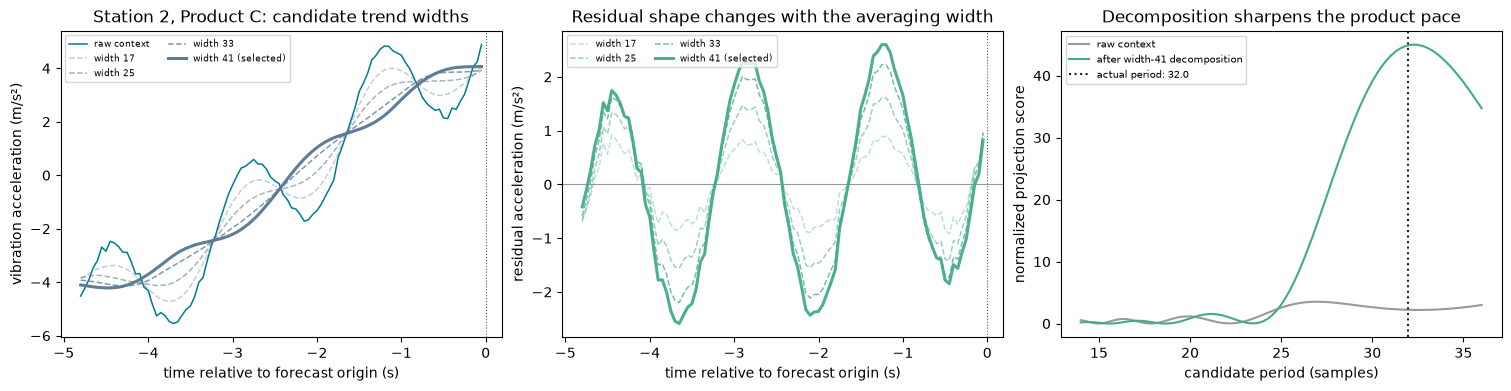

Output 2.2


,representation,oracle recovery within one sample,median absolute period error (samples),selected
0,raw,0.687,0.525,False
1,width 17,0.980,0.157,False
2,width 25,0.989,0.122,False
3,width 33,0.993,0.142,False
4,width 41,0.998,0.216,True


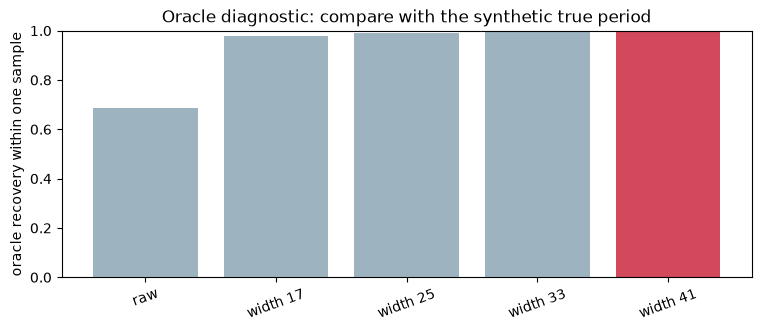

In [9]:
assert design.check_decomposition(SeriesDecomposition)
design.register_components(decomposition_type=SeriesDecomposition)

# Supplied Part 2 model: Attention mixes the remainder; a linear head forecasts the trend.
class DecompositionAttentionBlock(nn.Module):
    def __init__(self, d, heads, kernel, decomposition_type, dropout):
        super().__init__()
        self.mix = DenseAttention(d, heads)
        self.norm1, self.norm2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.feed_forward = nn.Sequential(
            nn.Linear(d, 2 * d), nn.GELU(), nn.Dropout(dropout), nn.Linear(2 * d, d))
        self.drop = nn.Dropout(dropout)
        self.strip1, self.strip2 = decomposition_type(kernel), decomposition_type(kernel)

    def forward(self, x):                       # [B,L,d]
        x, _ = self.strip1(x + self.drop(self.mix(self.norm1(x))))
        x, _ = self.strip2(x + self.drop(self.feed_forward(self.norm2(x))))
        return x                               # [B,L,d]

class DecomposedAttentionForecaster(nn.Module):
    def __init__(self, context=96, horizon=48, channels=1, d=64, heads=4, layers=2,
                 kernel=25, dropout=0.1, decomposition_type=None):
        super().__init__()
        self.split = decomposition_type(kernel)
        self.trend_head = nn.Linear(context, horizon)
        self.embed = nn.Conv1d(channels, d, 3, padding=1, padding_mode="circular", bias=False)
        self.position = nn.Parameter(torch.randn(1, context, d) * 0.02)
        self.blocks = nn.ModuleList([DecompositionAttentionBlock(
            d, heads, kernel, decomposition_type, dropout) for _ in range(layers)])
        self.norm = nn.LayerNorm(d)
        self.forecast_head = nn.Linear(context * d, horizon)

    def forward(self, context):                 # [B,L,1] -> [B,H]
        seasonal, trend = self.split(context)
        encoded = self.embed(seasonal.transpose(1, 2)).transpose(1, 2) + self.position
        for block in self.blocks:
            encoded = block(encoded)
        seasonal_forecast = self.forecast_head(self.norm(encoded).flatten(1))
        return seasonal_forecast + self.trend_head(trend.squeeze(-1))

    @property
    def attention_layers(self):
        return [block.mix for block in self.blocks]

assert design.check_decomposed_attention_assembly(DecomposedAttentionForecaster, SeriesDecomposition)
design.register_components(decomposed_attention_forecaster_type=DecomposedAttentionForecaster)
report.publish("2.1", figures.filter_decomposition(study))
report.publish("2.2", figures.recurrence_recovery(study))


Attention + decomposition: 6000 steps, 62.7s, 373024 parameters, best established-validation MSE 0.089 (m/s²)² -- same physical units as the report tables below
Attention + decomposition: saved attention-decomposition-full-data0-model0-0fb01b871304.pt
Output 2.3


,model,population,product,MSE,RMSE (m/s²),MAE (m/s²)
0,Raw Attention,established,Product A,0.176,0.419,0.314
1,Raw Attention,established,Product B,0.259,0.509,0.368
2,Raw Attention,established,Product C,0.199,0.446,0.328
3,Raw Attention,held-out,Product A,0.548,0.740,0.571
4,Raw Attention,held-out,Product B,0.470,0.686,0.490
5,Raw Attention,held-out,Product C,0.478,0.692,0.511
6,Attention + decomposition,established,Product A,0.076,0.276,0.211
7,Attention + decomposition,established,Product B,0.107,0.327,0.241
8,Attention + decomposition,established,Product C,0.085,0.291,0.217
9,Attention + decomposition,held-out,Product A,0.141,0.375,0.289


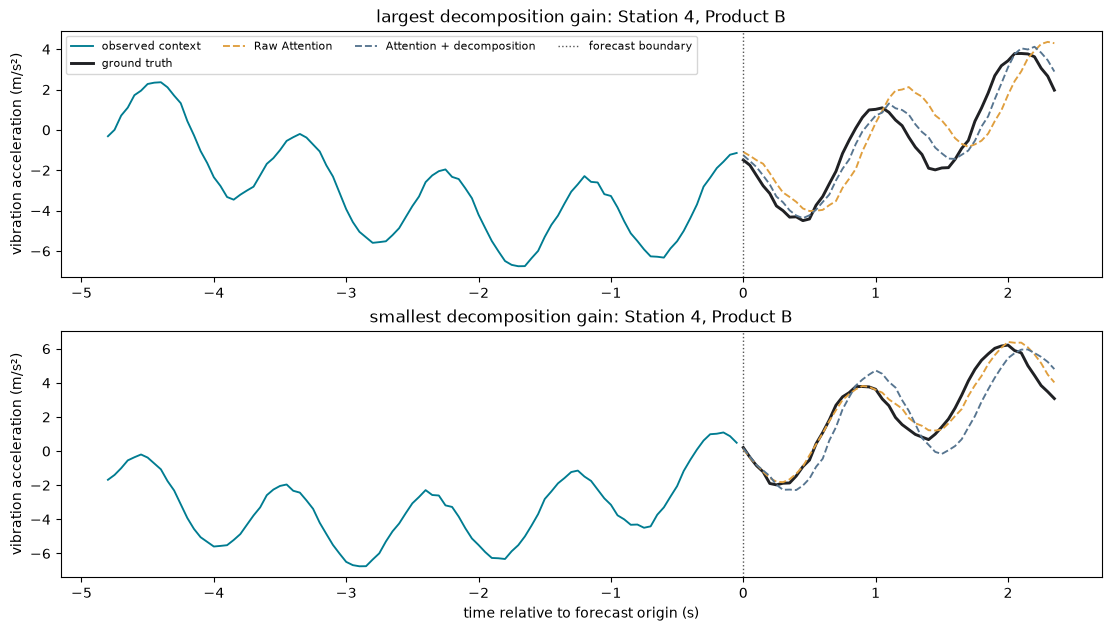

In [10]:
study.train("Attention + decomposition")
report.publish("2.3", figures.decomposition_ablation(study))


### My findings for Part 2 (Response 2)

- **Selected width:** 41 samples.
- **What I see in Output 2.1** (station 2, Product C, one validation window, true period 32.0):
  with width 17 the trend line still wiggles with the vibration, so part of the vibration lands in
  the trend and the remainder is small (spread 0.578 m/s²). With width 41 the trend is a smooth
  ramp and the remainder keeps the full swing (spread 1.572 m/s²). At both ends the width-41 trend
  goes flat, because the end value is repeated there, so the ends are less reliable than the
  middle. After the width-41 split the period score has one clear peak at 32. For the raw window
  it has no clear peak.
- **Output 2.2** (training part, stations 1–3): the period is found to within one sample in 68.7%
  of raw windows. After the split it is 98.0% (width 17), 98.9% (25), 99.3% (33) and 99.8% (41).
- **Output 2.3** (validation part): adding decomposition to Raw Attention lowers RMSE from 0.460
  to 0.299 on stations 1–3 (MSE 0.211 to 0.089) and from 0.706 to 0.444 on station 4. It helps on
  every product. On stations 1–3: A 0.419 to 0.276, B 0.509 to 0.327, C 0.446 to 0.291.
- **Why a moving average fits this world:** the drift is slow and the vibration is fast. Averaging
  over a stretch at least as long as one cycle cancels the ups and downs of the vibration and
  keeps the slow level. The simple linear head can then handle the ramp, and the encoder only has
  to handle the repeating part.
- **Why the oracle check is a fair way to pick the width:** the simulator knows the true period,
  so we can test directly whether the remainder still shows the repetition. It uses only training
  windows from stations 1–3, so the validation and test parts stay untouched, and the true period
  is never given to the model.
- The remainder is not the true repeating part. It is only what the average did not take out, and
  it still holds some slow drift, mostly near the ends.
- **Where this would fail:** a sudden jump in the level, for example a sensor that is re-calibrated
  in the middle of a window. The moving average spreads the jump over 41 samples, so the trend is
  wrong around it and the remainder gets a false bump that is not vibration.


## 3. Mix by Temporal Delay

Switch 2 replaces the mixer rather than changing what the mixer is shown. Delay mixing scores
every delay, keeps the best few from the fixed band, sharpens them with a learned temperature,
and combines shifted copies of the context. Scoring every delay (`delay_scores`) is supplied;
you write the aggregation (`aggregate_delays`) that turns scored delays into a mixed sequence.

The mental model is: **score delays → select useful delays → shift values → combine them.**

Produces **Outputs 3.1–3.2** → used in **Response 3**.


### Delay scores (supplied)

`delay_scores(queries, keys)` takes tensors of shape `(batch, heads, features, time)` and returns
one score per delay, of shape `(batch, time)`. It is supplied below: it computes every delay's
score with two real forward FFTs and one inverse real FFT, in `O(L log L)` rather than the
`O(L^2)` a loop over delays would cost. You do not need to derive or reconstruct this procedure.

| Cell below | Output | Read it for |
| --- | --- | --- |
| the supplied scores on `[1, 3, 1, 3]`, against a direct calculation | 3.1 | Response 3 |


In [11]:
def delay_scores(queries, keys):
    # queries, keys: [B,heads,features,L] -> scores [B,L], one per delay tau = 0 .. L-1.
    # R(tau) = sum_t q[t] * k[(t - tau) mod L], centered in time, averaged over heads and
    # features. Supplied: an FFT computes every delay's score together in O(L log L).
    queries = queries - queries.mean(-1, keepdim=True)
    keys = keys - keys.mean(-1, keepdim=True)
    spectrum = torch.fft.rfft(queries, dim=-1) * torch.fft.rfft(keys, dim=-1).conj()
    return torch.fft.irfft(spectrum, n=queries.shape[-1], dim=-1).mean((1, 2))


In [12]:
# delay_scores is supplied above. This toy example confirms it against a direct circular
# correlation for q = k = [1, 3, 1, 3], which centers to [-1, 1, -1, 1].
example = torch.tensor([1., 3., 1., 3.]).reshape(1, 1, 1, 4)
scores = pd.DataFrame({"delay": range(4),
                       "delay_scores (FFT)": delay_scores(example, example).flatten().tolist(),
                       "direct circular correlation": [4., -4., 4., -4.]})
display(scores.round(6))

assert design.check_delay_scores(delay_scores)
design.register_components(delay_scores=delay_scores)
report.publish("3.1", scores)


,delay,delay_scores (FFT),direct circular correlation
0,0,4.0,4.0
1,1,-4.0,-4.0
2,2,4.0,4.0
3,3,-4.0,-4.0


FFT delay-score checks passed.
Output 3.1


,delay,delay_scores (FFT),direct circular correlation
0,0,4.0,4.0
1,1,-4.0,-4.0
2,2,4.0,4.0
3,3,-4.0,-4.0


### Delay aggregation

`aggregate_delays(values, delays, weights)` takes `values` of shape
`(batch, heads, features, time)` plus `delays` and `weights` of shape `(batch, K)`, and returns the
weighted circular shifts, of shape `(batch, heads, features, time)` — the same shape as `values`.

Position `t` reads the value from `t - delay`, wrapping modulo `L`. Each example carries its own
delays and weights, shared across that example's heads and features.

The worked example below is the handout's aggregation case, and its first entry decides the direction:
`z0 = 35` means your shift runs the right way, `z0 = 25` means it runs backwards. That is the
single most common bug in this cell.

The next cell checks this aggregation immediately with the worked example and a gradient test.


In [13]:
def aggregate_delays(values, delays, weights):
    # values: [B,heads,features,L]; delays, weights: [B,K] -> [B,heads,features,L]
    # z[t] = sum_j weights[j] * values[(t - delays[j]) mod L], per example, shared across
    # that example's heads and features. Keep it differentiable in both values and weights.
    length = values.shape[-1]
    positions = torch.arange(length, device=values.device)
    mixed = torch.zeros_like(values)
    for j in range(delays.shape[-1]):
        source = (positions - delays[:, j, None]) % length              # [B,L]: t reads t - delay
        shifted = values.gather(-1, source[:, None, None, :].expand_as(values))
        mixed = mixed + weights[:, j, None, None, None] * shifted
    return mixed


In [14]:
# Let v = [10, 20, 30, 40], delays [1, 3], and weights [3/4, 1/4].
# z0 = 3/4 * v[3] + 1/4 * v[1] = 30 + 5 = 35. If you get 25, the shift runs the wrong way.
values = torch.tensor([10., 20., 30., 40.]).reshape(1, 1, 1, 4)
mixed = aggregate_delays(values, torch.tensor([[1, 3]]), torch.tensor([[.75, .25]]))
aggregated = pd.DataFrame({"position": range(4),
                           "your aggregated value": mixed.flatten(),
                           "expected": [35., 15., 25., 25.]})
display(aggregated.round(6))

assert design.check_aggregation(aggregate_delays)
design.register_components(aggregate=aggregate_delays)


,position,your aggregated value,expected
0,0,35.0,35.0
1,1,15.0,15.0
2,2,25.0,25.0
3,3,25.0,25.0


Delay-aggregation checks passed.


### Delay mixer (supplied)

`DelayMixer` applies the full sequence: it projects the context into q/k/v features, calls the
supplied scorer, selects useful delays, and calls your aggregation function to combine the
shifted values.


In [15]:
class DelayMixer(nn.Module):
    def __init__(self, d, heads, delay_score_fn, aggregate_fn, min_delay=8, max_delay=48):
        super().__init__()
        if d % heads:
            raise ValueError("width must be divisible by heads")
        self.heads, self.min_delay, self.max_delay = heads, min_delay, max_delay
        self.delay_score_fn, self.aggregate_fn = delay_score_fn, aggregate_fn
        self.query, self.key, self.value = (nn.Linear(d, d) for _ in range(3))
        self.out = nn.Linear(d, d)
        self.raw_temperature = nn.Parameter(torch.tensor(0.5413248546))

    @property
    def temperature(self):
        return F.softplus(self.raw_temperature) + 1e-6

    def forward(self, x):                       # [B,L,d]
        batch, length, width = x.shape
        shape = (batch, length, self.heads, width // self.heads)
        q, k, v = (layer(x).view(shape).permute(0, 2, 3, 1)
                   for layer in (self.query, self.key, self.value))  # [B,h,d_h,L]
        scores = self.delay_score_fn(q, k)      # [B,L]
        lo, hi = self.min_delay, min(self.max_delay, length - 1)
        band = scores[:, lo:hi + 1]
        top_k = min(math.ceil(2 * math.log(length)), band.shape[-1])
        selected, indices = band.topk(top_k, dim=-1)
        delays = indices + lo                  # [B,K]
        weights = (selected / self.temperature).softmax(-1)  # [B,K]
        mixed = self.aggregate_fn(v, delays, weights)         # [B,h,d_h,L]
        return self.out(mixed.permute(0, 3, 1, 2).reshape(batch, length, width))


### Output 3.2 — Signal-level recurrence diagnostic

This diagnostic correlates raw and residual **signal values** directly. It does **not** show the
trained mixer's learned q/k delay scores. It makes the repeating-delay assumption visible; the
model scores learned projected features.


Output 3.2


,station,product,expected delay (samples),nearest integer delay,residual signal correlation
0,2,Product A,16.135,16,0.896
1,2,Product A,32.269,32,0.897


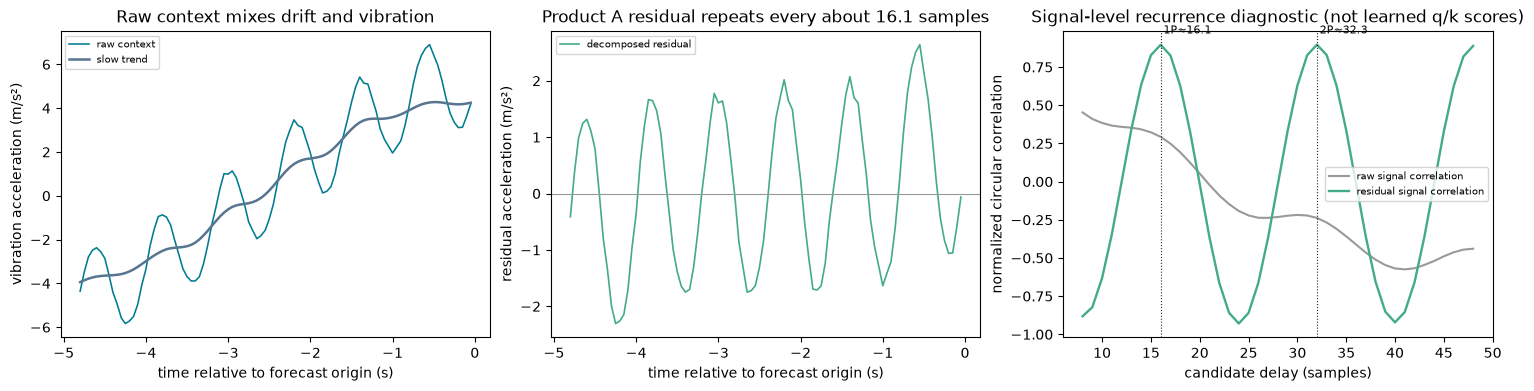

In [16]:
recurrence = figures.delay_recurrence(study)
report.publish("3.2", recurrence)


### My findings for Part 3 (Response 3)

- **Check of my code:** the worked example gives 35, 15, 25, 25, the same as expected. The first
  value is 35, so the shift runs the right way. The supplied delay scores in Output 3.1 match the
  direct calculation (4, −4, 4, −4).
- **Strongest lags in Output 3.2** (station 2, Product A, one validation window, true period
  P = 16.1): the remainder repeats most strongly at lag 16 (correlation 0.896) and lag 32 (0.897).
  These are P and 2P. The curve rises again close to lag 48, which is near 3P. Halfway between
  these lags it is strongly negative, because a peak then meets a dip.
- **Why removing the drift first makes it cleaner:** in the raw window the curve has no peak at 16
  or 32. It just slides down smoothly as the lag grows. The drift is a large ramp, and a ramp
  compared with a shifted copy of itself gives almost the same answer at every lag, so it buries
  the small vibration. Once the trend is taken out, only lags that match the cycle line up.
- **Why this supports delay mixing:** a few lags (P and its multiples) carry almost all of the
  useful information. Picking a small number of best delays and reusing values from that far back
  is built on exactly this.
- This figure is computed from the signal values. It is not the scores learned by the model, which
  compares learned features.
- **Where the assumption is wrong:** a one-off event, such as a single knock on the machine. It
  happens once, so no lag makes it line up with an earlier copy of itself. The delay mixer would
  still copy values from one cycle back, so it would miss the knock, and later it would paste the
  knock into places where nothing happened.


## 4. Compare Designs and Deploy

Nothing new to implement. Before running Output 4.1, write the prediction requested in
**Response 4** in at most two sentences. You now know both switches, so this part introduces the
supplied unified network. The four models are that one network with the two switches thrown
differently. The combined decomposed-delay configuration is called **Autoformer-inspired**.
They share width, depth, data order, optimizer schedule, and
checkpoint policy; they do **not** share parameter count or runtime, which Output 4.1 reports in
separate columns.

Produces **Outputs 4.1–4.3** → used in **Response 4**.

| Cell below | Output | Read it for |
| --- | --- | --- |
| fit the two remaining models; comparison table and contrasting forecast cases | 4.1 | Response 4 — write its prediction first |
| error along the 48-step horizon | 4.2 | Response 4 |
| selected models and their validation/test results | 4.3 | Response 4 |


### My prediction for Response 4(a) (written before running Output 4.1)

I expect decomposition to help the most when the slow part is large, because it takes the slow
ramp out of the window and gives it to a simple linear head, so the mixer only has to deal with
the repeating part. The delay mixer on its own should help less there, because a big ramp still
looks like itself after almost any shift, and that can hide the real repeat spacing.


Model assembly and gradient checks passed (4 setting(s): raw/attention, raw/delay, decomposed/attention, decomposed/delay).


Raw delay mixer: 6000 steps, 68.5s, 368370 parameters, best established-validation MSE 0.045 (m/s²)² -- same physical units as the report tables below
Raw delay mixer: saved raw-delay-mixer-full-data0-model0-ad0d4fd609a5.pt
Autoformer-inspired: 6000 steps, 81.6s, 373026 parameters, best established-validation MSE 0.039 (m/s²)² -- same physical units as the report tables below
Autoformer-inspired: saved autoformer-inspired-full-data0-model0-a29ef1200094.pt
Output 4.1


,model,established stations RMSE (m/s²),established stations MSE (m/s²)²,"established stations, Product A RMSE","established stations, Product B RMSE","established stations, Product C RMSE",held-out station 4 RMSE (m/s²),held-out station 4 MSE (m/s²)²,"held-out station 4, Product A RMSE","held-out station 4, Product B RMSE","held-out station 4, Product C RMSE",parameters,fit seconds
0,Raw Attention,0.460,0.211,0.419,0.509,0.446,0.706,0.499,0.740,0.686,0.692,368368,51.211
1,Raw delay mixer,0.212,0.045,0.208,0.213,0.216,0.332,0.110,0.395,0.280,0.311,368370,68.529
2,Attention + decomposition,0.299,0.089,0.276,0.327,0.291,0.444,0.198,0.375,0.507,0.441,373024,62.686
3,Autoformer-inspired,0.199,0.039,0.226,0.185,0.182,0.248,0.062,0.281,0.227,0.233,373026,81.645


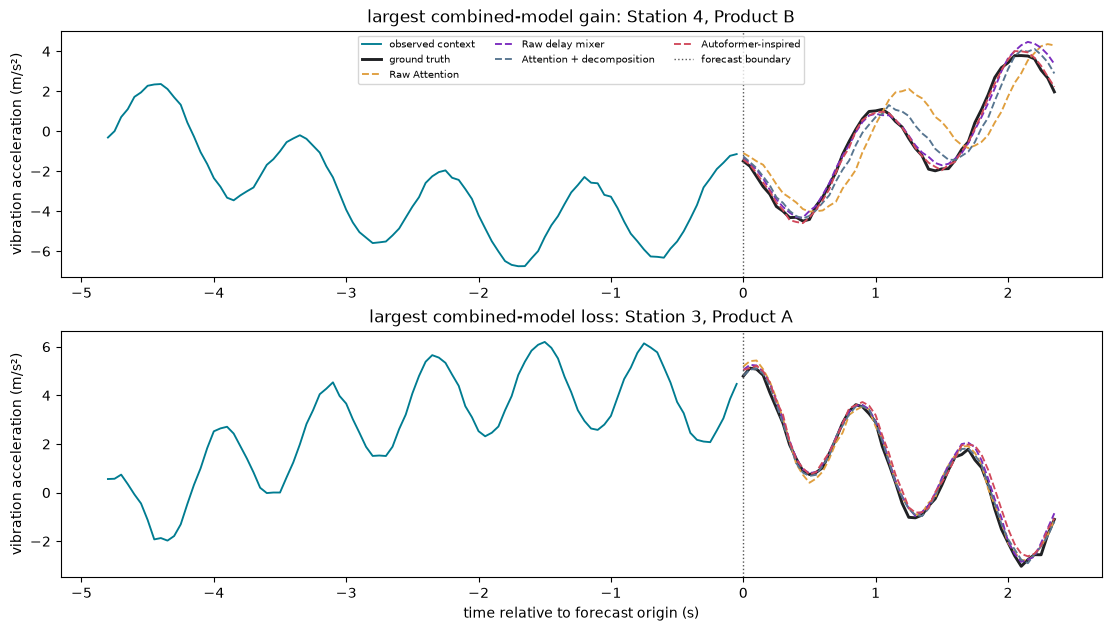

,case,station,product,model,window RMSE (m/s²)
0,largest combined-model gain,4,Product B,Raw Attention,1.550
1,largest combined-model gain,4,Product B,Raw delay mixer,0.425
2,largest combined-model gain,4,Product B,Attention + decomposition,0.683
3,largest combined-model gain,4,Product B,Autoformer-inspired,0.166
4,largest combined-model loss,3,Product A,Raw Attention,0.231
5,largest combined-model loss,3,Product A,Raw delay mixer,0.229
6,largest combined-model loss,3,Product A,Attention + decomposition,0.151
7,largest combined-model loss,3,Product A,Autoformer-inspired,0.338


In [17]:
# Supplied unified 2×2 design.
class IdentitySplit(nn.Module):
    def forward(self, x):
        return x, torch.zeros_like(x)

class EncoderBlock(nn.Module):
    def __init__(self, d, heads, mixing, kernel, decomposition_type,
                 delay_score_fn, aggregate_fn, dropout):
        super().__init__()
        self.mix = (DelayMixer(d, heads, delay_score_fn, aggregate_fn)
                    if mixing == "delay" else DenseAttention(d, heads))
        self.norm1, self.norm2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.feed_forward = nn.Sequential(
            nn.Linear(d, 2 * d), nn.GELU(), nn.Dropout(dropout), nn.Linear(2 * d, d))
        self.drop = nn.Dropout(dropout)
        split = decomposition_type if decomposition_type is not None else lambda _: IdentitySplit()
        self.strip1, self.strip2 = split(kernel), split(kernel)

    def forward(self, x):                       # [B,L,d]
        x, _ = self.strip1(x + self.drop(self.mix(self.norm1(x))))
        x, _ = self.strip2(x + self.drop(self.feed_forward(self.norm2(x))))
        return x                               # [B,L,d]

class AutoformerInspiredForecaster(nn.Module):
    def __init__(self, context=96, horizon=48, channels=1, d=64, heads=4, layers=2,
                 mixing="attention", representation="raw", kernel=25, dropout=0.1,
                 decomposition_type=None, delay_score_fn=None, aggregate_fn=None):
        super().__init__()
        if representation not in {"raw", "decomposed"}:
            raise ValueError("representation must be 'raw' or 'decomposed'")
        self.split = (decomposition_type(kernel) if representation == "decomposed"
                      else IdentitySplit())
        self.trend_head = nn.Linear(context, horizon) if representation == "decomposed" else None
        self.embed = nn.Conv1d(channels, d, 3, padding=1, padding_mode="circular", bias=False)
        self.position = nn.Parameter(torch.randn(1, context, d) * 0.02)
        self.blocks = nn.ModuleList([EncoderBlock(
            d, heads, mixing, kernel, decomposition_type, delay_score_fn, aggregate_fn, dropout)
            for _ in range(layers)])
        self.norm = nn.LayerNorm(d)
        self.forecast_head = nn.Linear(context * d, horizon)

    def forward(self, context):                 # [B,L,1] -> [B,H]
        seasonal, trend = self.split(context)
        encoded = self.embed(seasonal.transpose(1, 2)).transpose(1, 2) + self.position
        for block in self.blocks:
            encoded = block(encoded)
        seasonal_forecast = self.forecast_head(self.norm(encoded).flatten(1))
        trend_forecast = 0 if self.trend_head is None else self.trend_head(trend.squeeze(-1))
        return seasonal_forecast + trend_forecast

    @property
    def attention_layers(self):
        return [block.mix for block in self.blocks if isinstance(block.mix, DenseAttention)]

    @property
    def delay_layers(self):
        return [block.mix for block in self.blocks if isinstance(block.mix, DelayMixer)]

assert design.check_assembly(AutoformerInspiredForecaster)
design.register_components(forecaster_type=AutoformerInspiredForecaster)
study.train("Raw delay mixer")
study.train("Autoformer-inspired")
cases = figures.contrasting_forecasts(study)
report.publish("4.1", report.comparison(study, [
    "Raw Attention", "Raw delay mixer", "Attention + decomposition", "Autoformer-inspired"]))
display(cases.round(3))


Output 4.2


,model,population,horizon,MSE,RMSE (m/s²)
0,Period-routed ridge,established,1,0.013,0.112
1,Period-routed ridge,established,2,0.011,0.107
2,Period-routed ridge,established,3,0.014,0.118
3,Period-routed ridge,established,4,0.014,0.118
4,Period-routed ridge,established,5,0.015,0.121
...,...,...,...,...,...
475,Autoformer-inspired,held-out,44,0.111,0.333
476,Autoformer-inspired,held-out,45,0.121,0.349
477,Autoformer-inspired,held-out,46,0.108,0.329
478,Autoformer-inspired,held-out,47,0.111,0.334


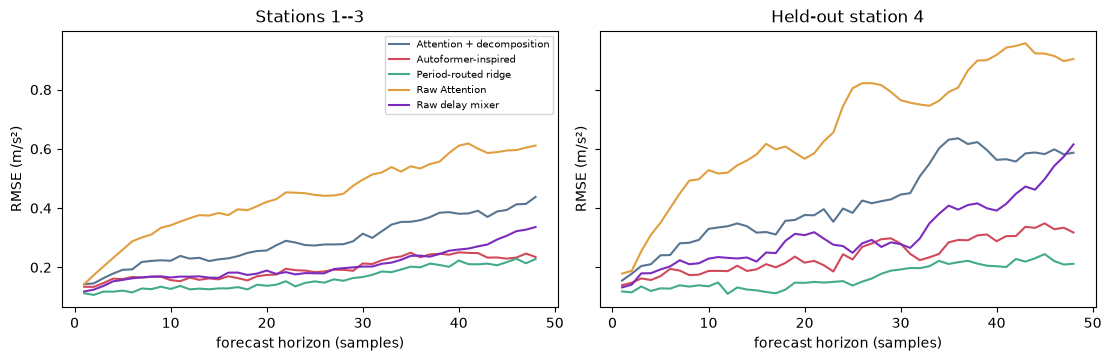

In [18]:
report.publish("4.2", figures.horizon_figure(study, [
    "Period-routed ridge", "Raw Attention", "Raw delay mixer",
    "Attention + decomposition", "Autoformer-inspired"]))


### Choose the deployment models (Response 4)

Choose one fitted model for the established stations and one for held-out station 4 using validation
MSE, physical-unit RMSE, parameter count, and fitting time,
then enter both model names below. Output 4.3 reports their validation and test results.

The compact validation-only decision summary below collects the error and cost quantities needed
for this choice. It is not another Output; Outputs 1.1 and 4.1–4.2 remain the detailed evidence.

| Cell below | Output | Read it for |
| --- | --- | --- |
| enter both choices | — | Response 4 |
| validation/test results for both choices | 4.3 | Response 4 |


In [19]:
# Validation-only decision summary.
display(report.deployment_summary(study).round(3))


,model,established validation RMSE (m/s²),established validation MSE (m/s²)²,held-out validation RMSE (m/s²),held-out validation MSE (m/s²)²,parameters,fit seconds
0,Shared ridge,0.767,0.588,0.876,0.767,4608,0.009
1,Sensor-specific ridge,0.768,0.590,NaN,NaN,13824,0.002
2,Period-routed ridge,0.166,0.028,0.173,0.030,59904,0.004
3,Raw Attention,0.460,0.211,0.706,0.499,368368,51.211
4,Attention + decomposition,0.299,0.089,0.444,0.198,373024,62.686
5,Raw delay mixer,0.212,0.045,0.332,0.110,368370,68.529
6,Autoformer-inspired,0.199,0.039,0.248,0.062,373026,81.645


### My findings for Response 4(b) and 4(c)

Validation part only, written before Output 4.3.

| Model (validation, stations 1–3) | RMSE (m/s²) | MSE (m/s²)² |
| --- | --- | --- |
| Shared ridge | 0.767 | 0.588 |
| Sensor-specific ridge | 0.768 | 0.590 |
| Period-routed ridge | 0.166 | 0.028 |
| Raw Attention | 0.460 | 0.211 |
| Raw delay mixer | 0.212 | 0.045 |
| Attention + decomposition | 0.299 | 0.089 |
| Autoformer-inspired | 0.199 | 0.039 |

**(b)** On stations 1–3, both switches help. Decomposition lowers RMSE from 0.460 to 0.299 with
Attention, but only from 0.212 to 0.199 with delay mixing. Delay mixing lowers it from 0.460 to
0.212 on raw input and from 0.299 to 0.199 on decomposed input. Delay mixing helps more, and
gains overlap instead of adding up. Error grows along the horizon: from step 1 to step 48, Raw Attention goes from 0.143 to 0.611 and period-routed ridge from 0.112 to 0.228.

**(c)** Stations 1–3: **Period-routed ridge**. Lowest validation RMSE (0.166 against 0.199 for
Autoformer-inspired), 59,904 parameters against 373,026, and fits in under a second against
82 seconds.

Station 4: **Period-routed ridge**. Validation RMSE 0.173 against 0.248 for Autoformer-inspired,
same cost.


In [20]:
choices = {
    "established": "Period-routed ridge",  # exact fitted model name chosen from validation evidence
    "held-out": "Period-routed ridge",
}
display(study.select_for_test(choices))


,population,model
0,established,Period-routed ridge
1,held-out,Period-routed ridge


In [21]:
report.publish("4.3", study.selected_test_table())


Output 4.3


,population,model,validation MSE,validation RMSE (m/s²),test MSE,test RMSE (m/s²)
0,established,Period-routed ridge,0.028,0.166,0.026,0.161
1,held-out,Period-routed ridge,0.030,0.173,0.033,0.183
